# VLM / AVL / LiftingLine Validation Plots

This notebook visualizes the validation sweep generated by `vlm_avl_liftingline_validation.py`. It compares AeroSandbox `VortexLatticeMethod` and `LiftingLine` against AVL for force coefficients, moment coefficients, and stability derivatives on the notional conventional aircraft with horizontal and vertical tails.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import numpy as np
import pandas as pd
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

script_candidates = [
    Path("vlm_avl_liftingline_validation.py"),
    Path("studies/TSher_Improvements/vlm_avl_liftingline_validation.py"),
]
SCRIPT = next((p.resolve() for p in script_candidates if p.exists()), None)
if SCRIPT is None:
    raise FileNotFoundError("Could not find vlm_avl_liftingline_validation.py. Run this notebook from the repo root or from studies/TSher_Improvements.")

ROOT = SCRIPT.parents[2]
OUTPUT_DIR = SCRIPT.parent / "vlm_avl_liftingline_validation_outputs"

# Flip this to True to force a fresh AVL/VLM/LiftingLine sweep before plotting.
RUN_VALIDATION = False

if RUN_VALIDATION or not (OUTPUT_DIR / "summary.json").exists():
    subprocess.run([sys.executable, str(SCRIPT)], cwd=ROOT, check=True)

summary = json.loads((OUTPUT_DIR / "summary.json").read_text())
force_df = pd.read_csv(OUTPUT_DIR / "force_coefficients.csv")
force_comparison_df = pd.read_csv(OUTPUT_DIR / "force_coefficient_comparisons.csv")
derivative_df = pd.read_csv(OUTPUT_DIR / "stability_derivatives.csv")
derivative_comparison_df = pd.read_csv(OUTPUT_DIR / "stability_derivative_comparisons.csv")
distribution_df = pd.read_csv(OUTPUT_DIR / "spanwise_distribution_checks.csv")

method_order = ["AVL", "VLM", "LiftingLine"]
method_style = {
    "AVL": {"color": "black", "marker": "o", "linewidth": 2.5},
    "VLM": {"color": "tab:blue", "marker": "s", "linewidth": 2.0},
    "LiftingLine": {"color": "tab:orange", "marker": "^", "linewidth": 2.0},
}

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

force_df.head()

,case,method,alpha,beta,p,q,r,CL,CD,CY,Cl,Cm,Cn
0,alpha_-4,AVL,-4.0,0.0,0.0,0.0,0.0,-0.359330,0.004930,0.000000e+00,-0.000000e+00,0.081660,-0.000000e+00
1,alpha_-4,VLM,-4.0,0.0,0.0,0.0,0.0,-0.377544,0.005350,-1.372782e-17,3.245712e-17,0.112425,4.766520e-18
2,alpha_-4,LiftingLine,-4.0,0.0,0.0,0.0,0.0,-0.397518,0.013495,1.238645e-17,1.017915e-17,0.121876,-7.471165e-18
3,alpha_+0,AVL,0.0,0.0,0.0,0.0,0.0,0.002460,0.000160,0.000000e+00,0.000000e+00,0.020600,-0.000000e+00
4,alpha_+0,VLM,0.0,0.0,0.0,0.0,0.0,-0.008110,0.000202,-1.254162e-18,1.316721e-18,0.021967,2.928695e-19


## Geometry Used In The Validation

In [2]:
import importlib.util

spec = importlib.util.spec_from_file_location("vlm_avl_validation", SCRIPT)
validation = importlib.util.module_from_spec(spec)
spec.loader.exec_module(validation)

airplane, geometry_metadata = validation.make_airplane()

geometry_summary = pd.DataFrame([
    {"quantity": "s_ref", "value": airplane.s_ref, "units": "m^2"},
    {"quantity": "c_ref", "value": airplane.c_ref, "units": "m"},
    {"quantity": "b_ref", "value": airplane.b_ref, "units": "m"},
    {"quantity": "xyz_ref / CG x", "value": airplane.xyz_ref[0], "units": "m"},
    {"quantity": "xyz_ref / CG y", "value": airplane.xyz_ref[1], "units": "m"},
    {"quantity": "xyz_ref / CG z", "value": airplane.xyz_ref[2], "units": "m"},
    {"quantity": "CG fraction MAC", "value": geometry_metadata["cg_fraction_mac"], "units": "-"},
])

wing_summary_rows = []
for wing_index, wing in enumerate(airplane.wings):
    aerodynamic_center = wing.aerodynamic_center()
    wing_summary_rows.append({
        "wing_index": wing_index,
        "wing": wing.name,
        "symmetric": wing.symmetric,
        "area_planform_m2": float(wing.area()),
        "span_yz_m": float(wing.span(type="yz", include_centerline_distance=True)),
        "mean_aerodynamic_chord_m": float(wing.mean_aerodynamic_chord()),
        "aerodynamic_center_x_m": float(aerodynamic_center[0]),
        "aerodynamic_center_y_m": float(aerodynamic_center[1]),
        "aerodynamic_center_z_m": float(aerodynamic_center[2]),
    })

wing_xsec_rows = []
for wing_index, wing in enumerate(airplane.wings):
    for xsec_index, xsec in enumerate(wing.xsecs):
        wing_xsec_rows.append({
            "wing_index": wing_index,
            "wing": wing.name,
            "symmetric": wing.symmetric,
            "xsec_index": xsec_index,
            "x_le_m": float(xsec.xyz_le[0]),
            "y_le_m": float(xsec.xyz_le[1]),
            "z_le_m": float(xsec.xyz_le[2]),
            "chord_m": float(xsec.chord),
            "twist_deg": float(xsec.twist),
            "airfoil": xsec.airfoil.name,
        })

display(geometry_summary)
display(pd.DataFrame(wing_summary_rows))
display(pd.DataFrame(wing_xsec_rows))

,quantity,value,units
0,s_ref,11.151326,m^2
1,c_ref,1.166904,m
2,b_ref,10.025780,m
3,xyz_ref / CG x,0.490742,m
4,xyz_ref / CG y,0.000000,m
5,xyz_ref / CG z,0.140132,m
6,CG fraction MAC,0.280000,-


,wing_index,wing,symmetric,area_planform_m2,span_yz_m,mean_aerodynamic_chord_m,aerodynamic_center_x_m,aerodynamic_center_y_m,aerodynamic_center_z_m
0,0,Main Wing,True,11.151326,10.025780,1.166904,0.455735,0.0,0.140132
1,1,Horizontal Tail,True,1.625891,2.903377,0.571667,5.025417,0.0,0.282083
2,2,Vertical Tail,False,0.810000,1.350000,0.634722,4.959375,0.0,0.781250


,wing_index,wing,symmetric,xsec_index,x_le_m,y_le_m,z_le_m,chord_m,twist_deg,airfoil
0,0,Main Wing,True,0,0.00,0.00,0.00,1.50,1.0,naca0012
1,0,Main Wing,True,1,0.15,2.50,0.15,1.15,0.0,naca0012
2,0,Main Wing,True,2,0.48,5.00,0.35,0.65,-2.0,naca0012
3,1,Horizontal Tail,True,0,4.80,0.00,0.25,0.70,0.0,naca0010
4,1,Horizontal Tail,True,1,4.98,1.45,0.32,0.42,0.0,naca0010
5,2,Vertical Tail,False,0,4.65,0.00,0.20,0.85,0.0,naca0010
6,2,Vertical Tail,False,1,5.00,0.00,1.55,0.35,0.0,naca0010


## Airplane Three-View

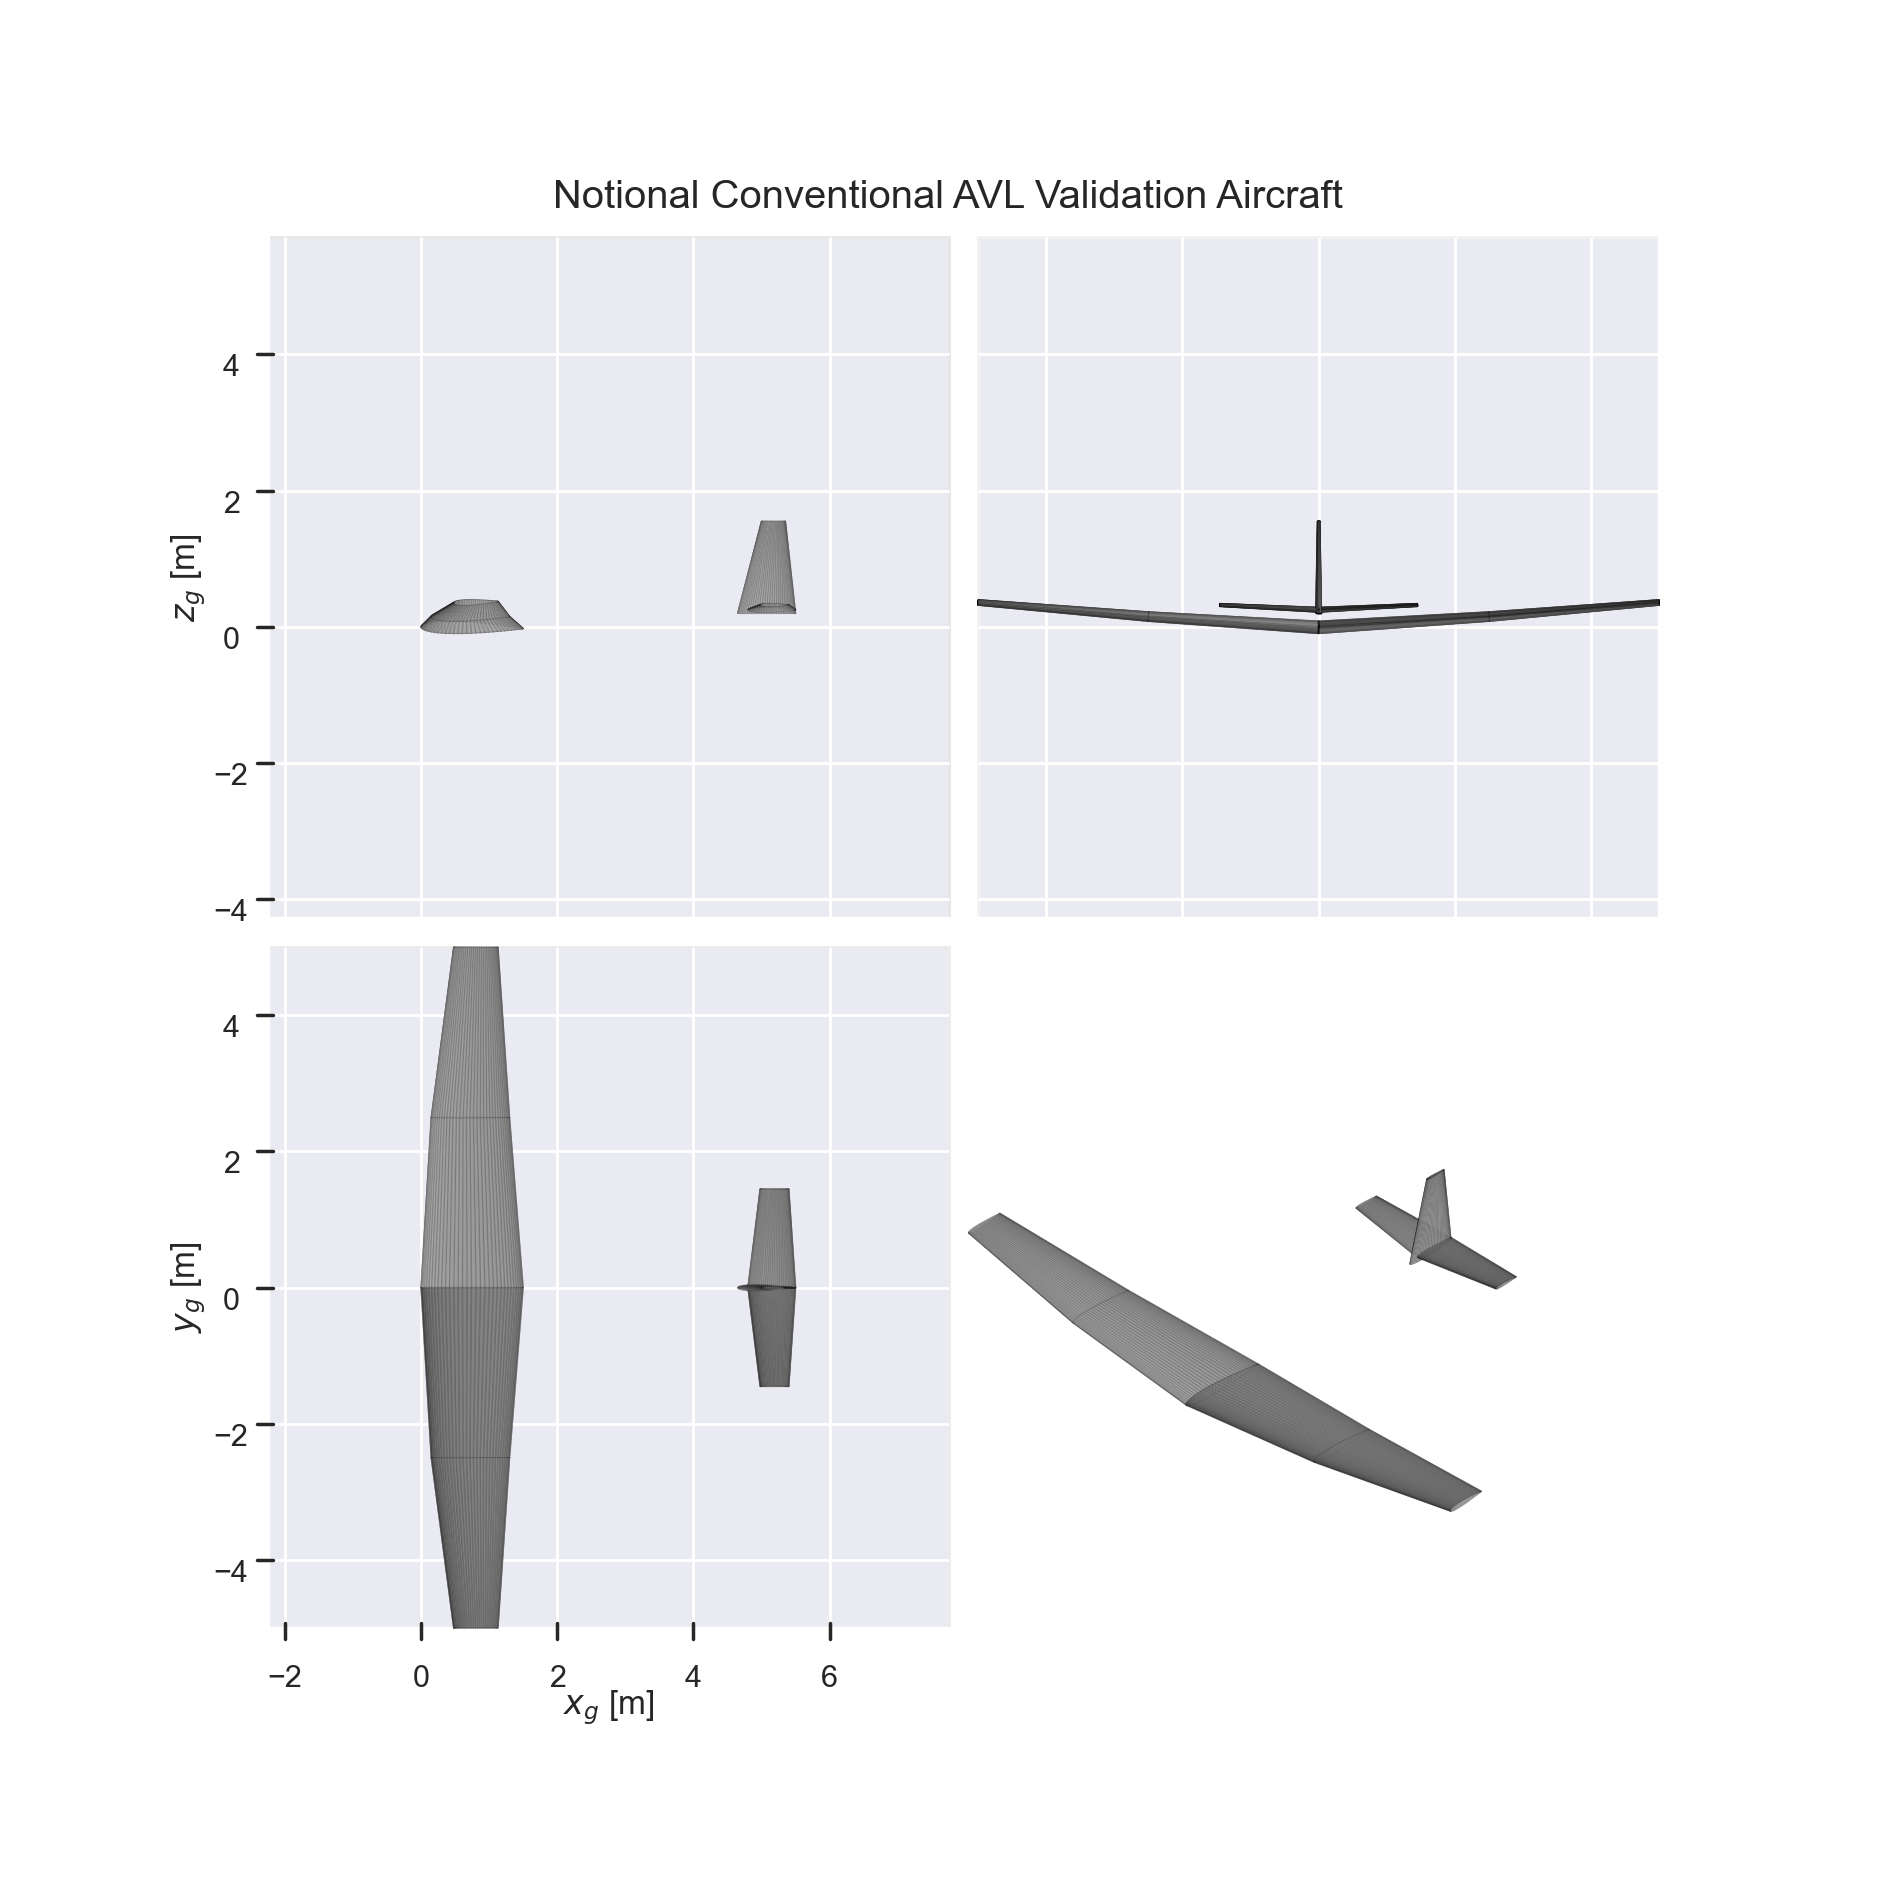

In [3]:
three_view_path = OUTPUT_DIR / "airplane_three_view.png"
axs = airplane.draw_three_view(show=False)
fig = axs[0, 0].figure
fig.suptitle("Notional Conventional AVL Validation Aircraft", y=0.98)
fig.savefig(three_view_path, dpi=200, bbox_inches="tight")
plt.close(fig)

display(Image(filename=str(three_view_path)))

## Validation Summary

In [4]:
summary_rows = [
    ["CG xyz_ref", summary["metadata"]["xyz_ref"]],
    ["CG fraction MAC", summary["metadata"]["cg_fraction_mac"]],
    ["AVL Xref/Yref/Zref max abs error", summary["cg_audit"]["max_abs_error"]],
    ["Shifted-CG moment-check abs error", summary["shifted_cg_moment_check"]["abs_error"]],
    ["Horizontal lift distribution checks pass", summary["horizontal_distribution_checks_pass"]],
    ["Worst VLM derivative abs error", summary["VLM_worst_derivative_abs_error"]],
    ["Worst LiftingLine derivative abs error", summary["LiftingLine_worst_derivative_abs_error"]],
]
pd.DataFrame(summary_rows, columns=["Metric", "Value"])

,Metric,Value
0,CG xyz_ref,"[0.4907421358174329, 0.0, 0.1401316016656464]"
1,CG fraction MAC,0.28
2,AVL Xref/Yref/Zref max abs error,0.0
3,Shifted-CG moment-check abs error,-0.0
4,Horizontal lift distribution checks pass,True
5,Worst VLM derivative abs error,"{'case': 'neutral', 'method': 'VLM', 'referenc..."
6,Worst LiftingLine derivative abs error,"{'case': 'design', 'method': 'LiftingLine', 'r..."


## Force And Moment Coefficients Vs. Angle Of Attack

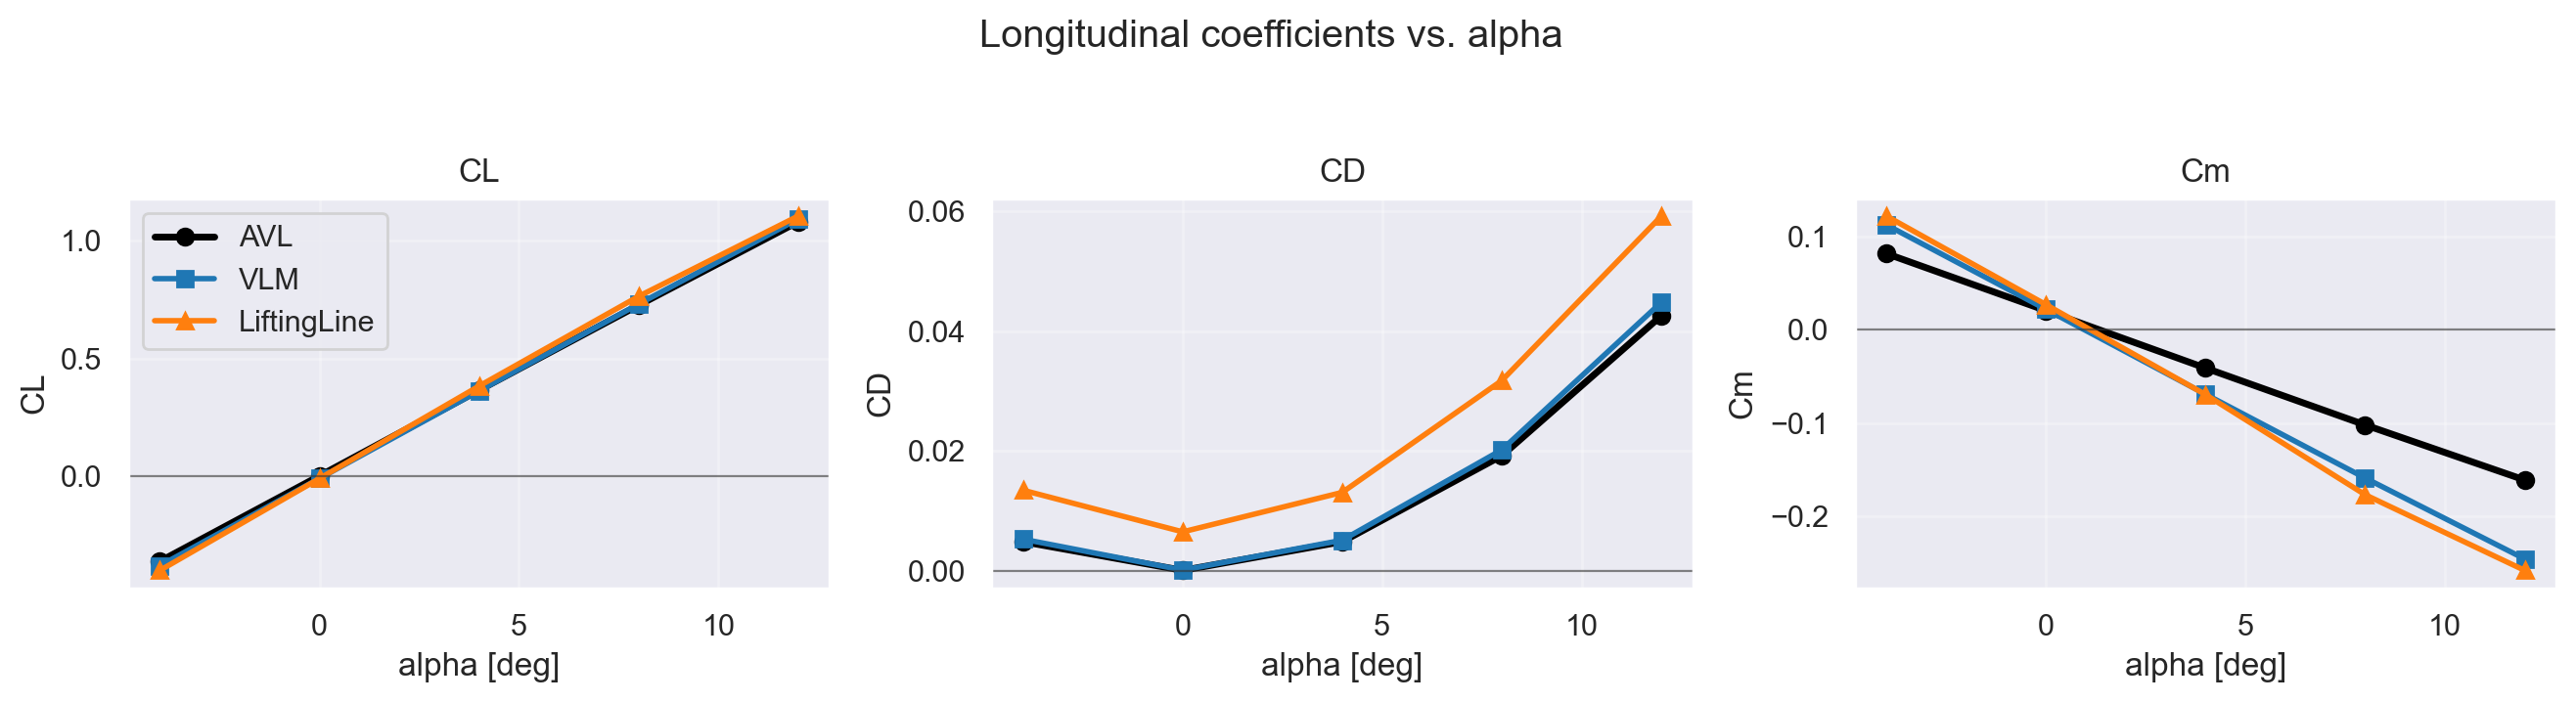

In [5]:
def plot_vs(df, x_col, y_cols, title, x_label=None):
    fig, axes = plt.subplots(1, len(y_cols), figsize=(4.5 * len(y_cols), 3.4), sharex=True)
    if len(y_cols) == 1:
        axes = [axes]

    for ax, y_col in zip(axes, y_cols):
        for method in method_order:
            sub = df[df["method"] == method].sort_values(x_col)
            ax.plot(sub[x_col], sub[y_col], label=method, **method_style[method])
        ax.set_xlabel(x_label or x_col)
        ax.set_ylabel(y_col)
        ax.set_title(y_col)
        ax.axhline(0, color="0.2", linewidth=0.8, alpha=0.6)
    axes[0].legend()
    fig.suptitle(title, y=1.05)
    fig.tight_layout()
    return fig, axes

alpha_df = force_df[force_df["case"].str.startswith("alpha_")].copy()
plot_vs(alpha_df, "alpha", ["CL", "CD", "Cm"], "Longitudinal coefficients vs. alpha", "alpha [deg]");

## Lateral Coefficients Vs. Sideslip

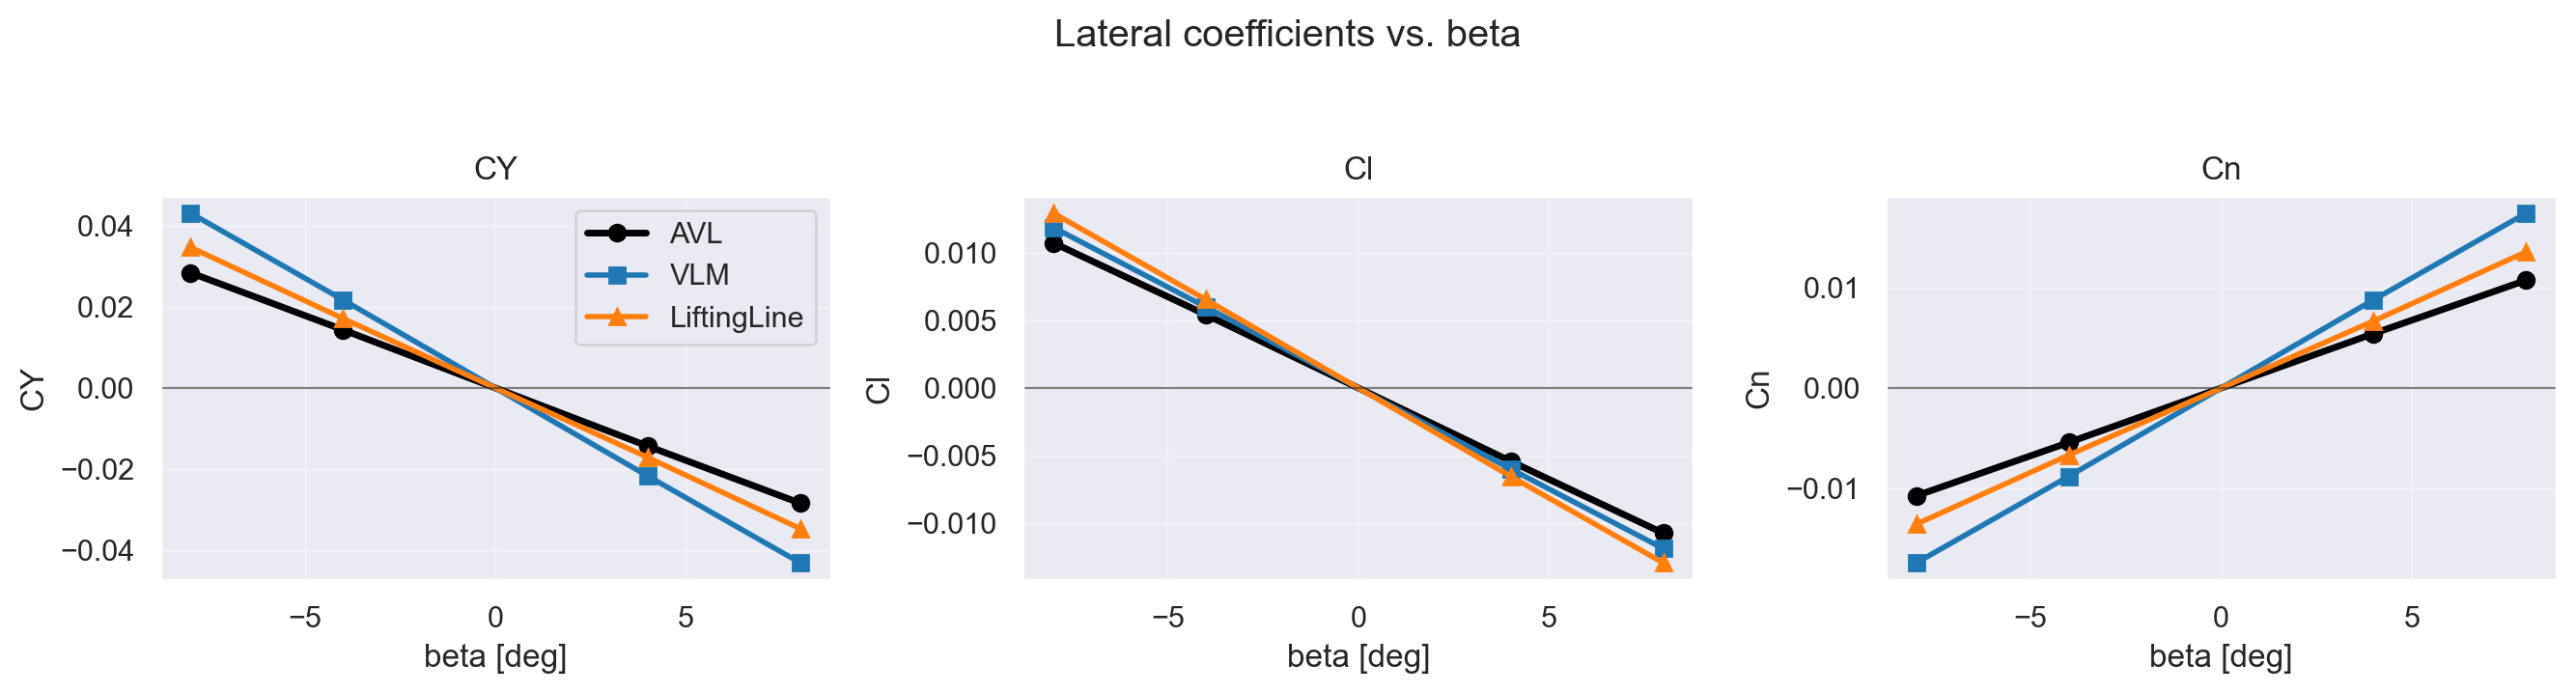

In [6]:
beta_df = force_df[force_df["case"].str.startswith("beta_")].copy()
plot_vs(beta_df, "beta", ["CY", "Cl", "Cn"], "Lateral coefficients vs. beta", "beta [deg]");

## Body-Rate Cases

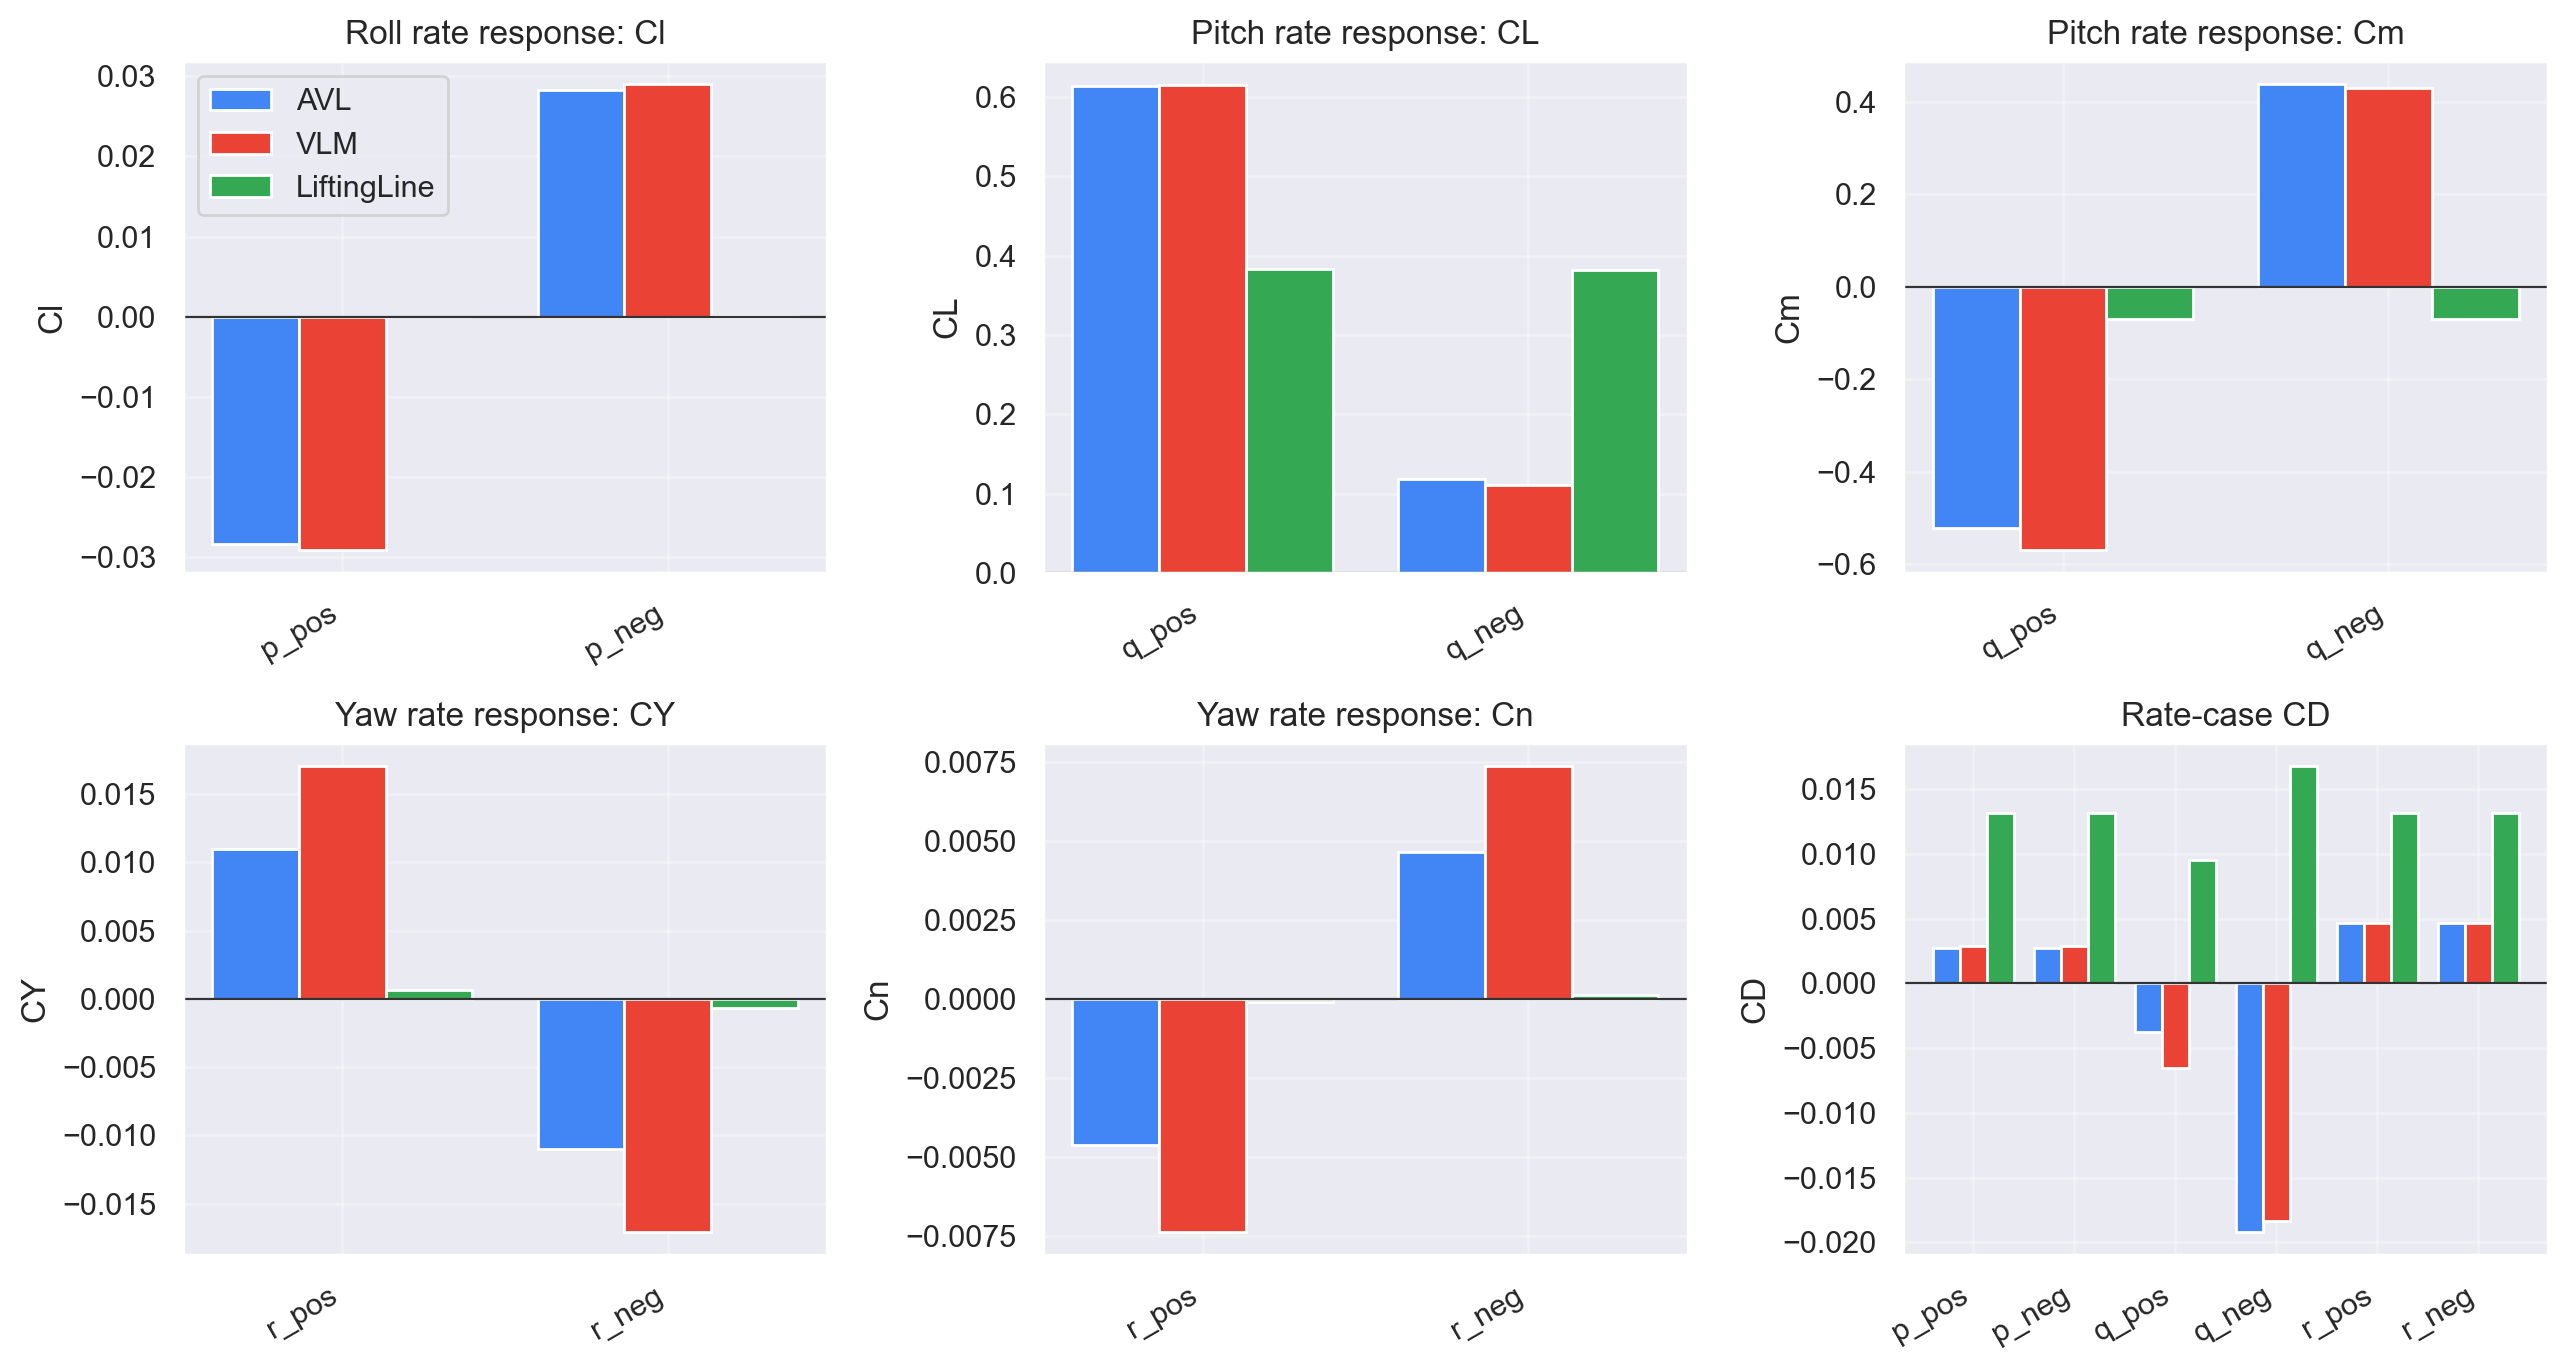

In [7]:
def grouped_bar(ax, df, category_col, value_col, title, ylabel=None):
    categories = list(dict.fromkeys(df[category_col]))
    x = np.arange(len(categories))
    width = 0.8 / len(method_order)

    for i, method in enumerate(method_order):
        sub = df[df["method"] == method].set_index(category_col).reindex(categories)
        offset = (i - (len(method_order) - 1) / 2) * width
        ax.bar(x + offset, sub[value_col], width=width, label=method)

    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=30, ha="right")
    ax.set_title(title)
    ax.set_ylabel(ylabel or value_col)
    ax.axhline(0, color="0.2", linewidth=0.8)

rate_df = force_df[force_df["case"].isin(["p_pos", "p_neg", "q_pos", "q_neg", "r_pos", "r_neg"])].copy()

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
rate_plots = [
    ("Cl", ["p_neg", "p_pos"], "Roll rate response: Cl"),
    ("CL", ["q_neg", "q_pos"], "Pitch rate response: CL"),
    ("Cm", ["q_neg", "q_pos"], "Pitch rate response: Cm"),
    ("CY", ["r_neg", "r_pos"], "Yaw rate response: CY"),
    ("Cn", ["r_neg", "r_pos"], "Yaw rate response: Cn"),
    ("CD", ["p_neg", "p_pos", "q_neg", "q_pos", "r_neg", "r_pos"], "Rate-case CD"),
]

for ax, (coefficient, cases, title) in zip(axes.flat, rate_plots):
    grouped_bar(ax, rate_df[rate_df["case"].isin(cases)], "case", coefficient, title, coefficient)

axes[0, 0].legend()
fig.tight_layout();

## Stability Derivatives At The Design Condition

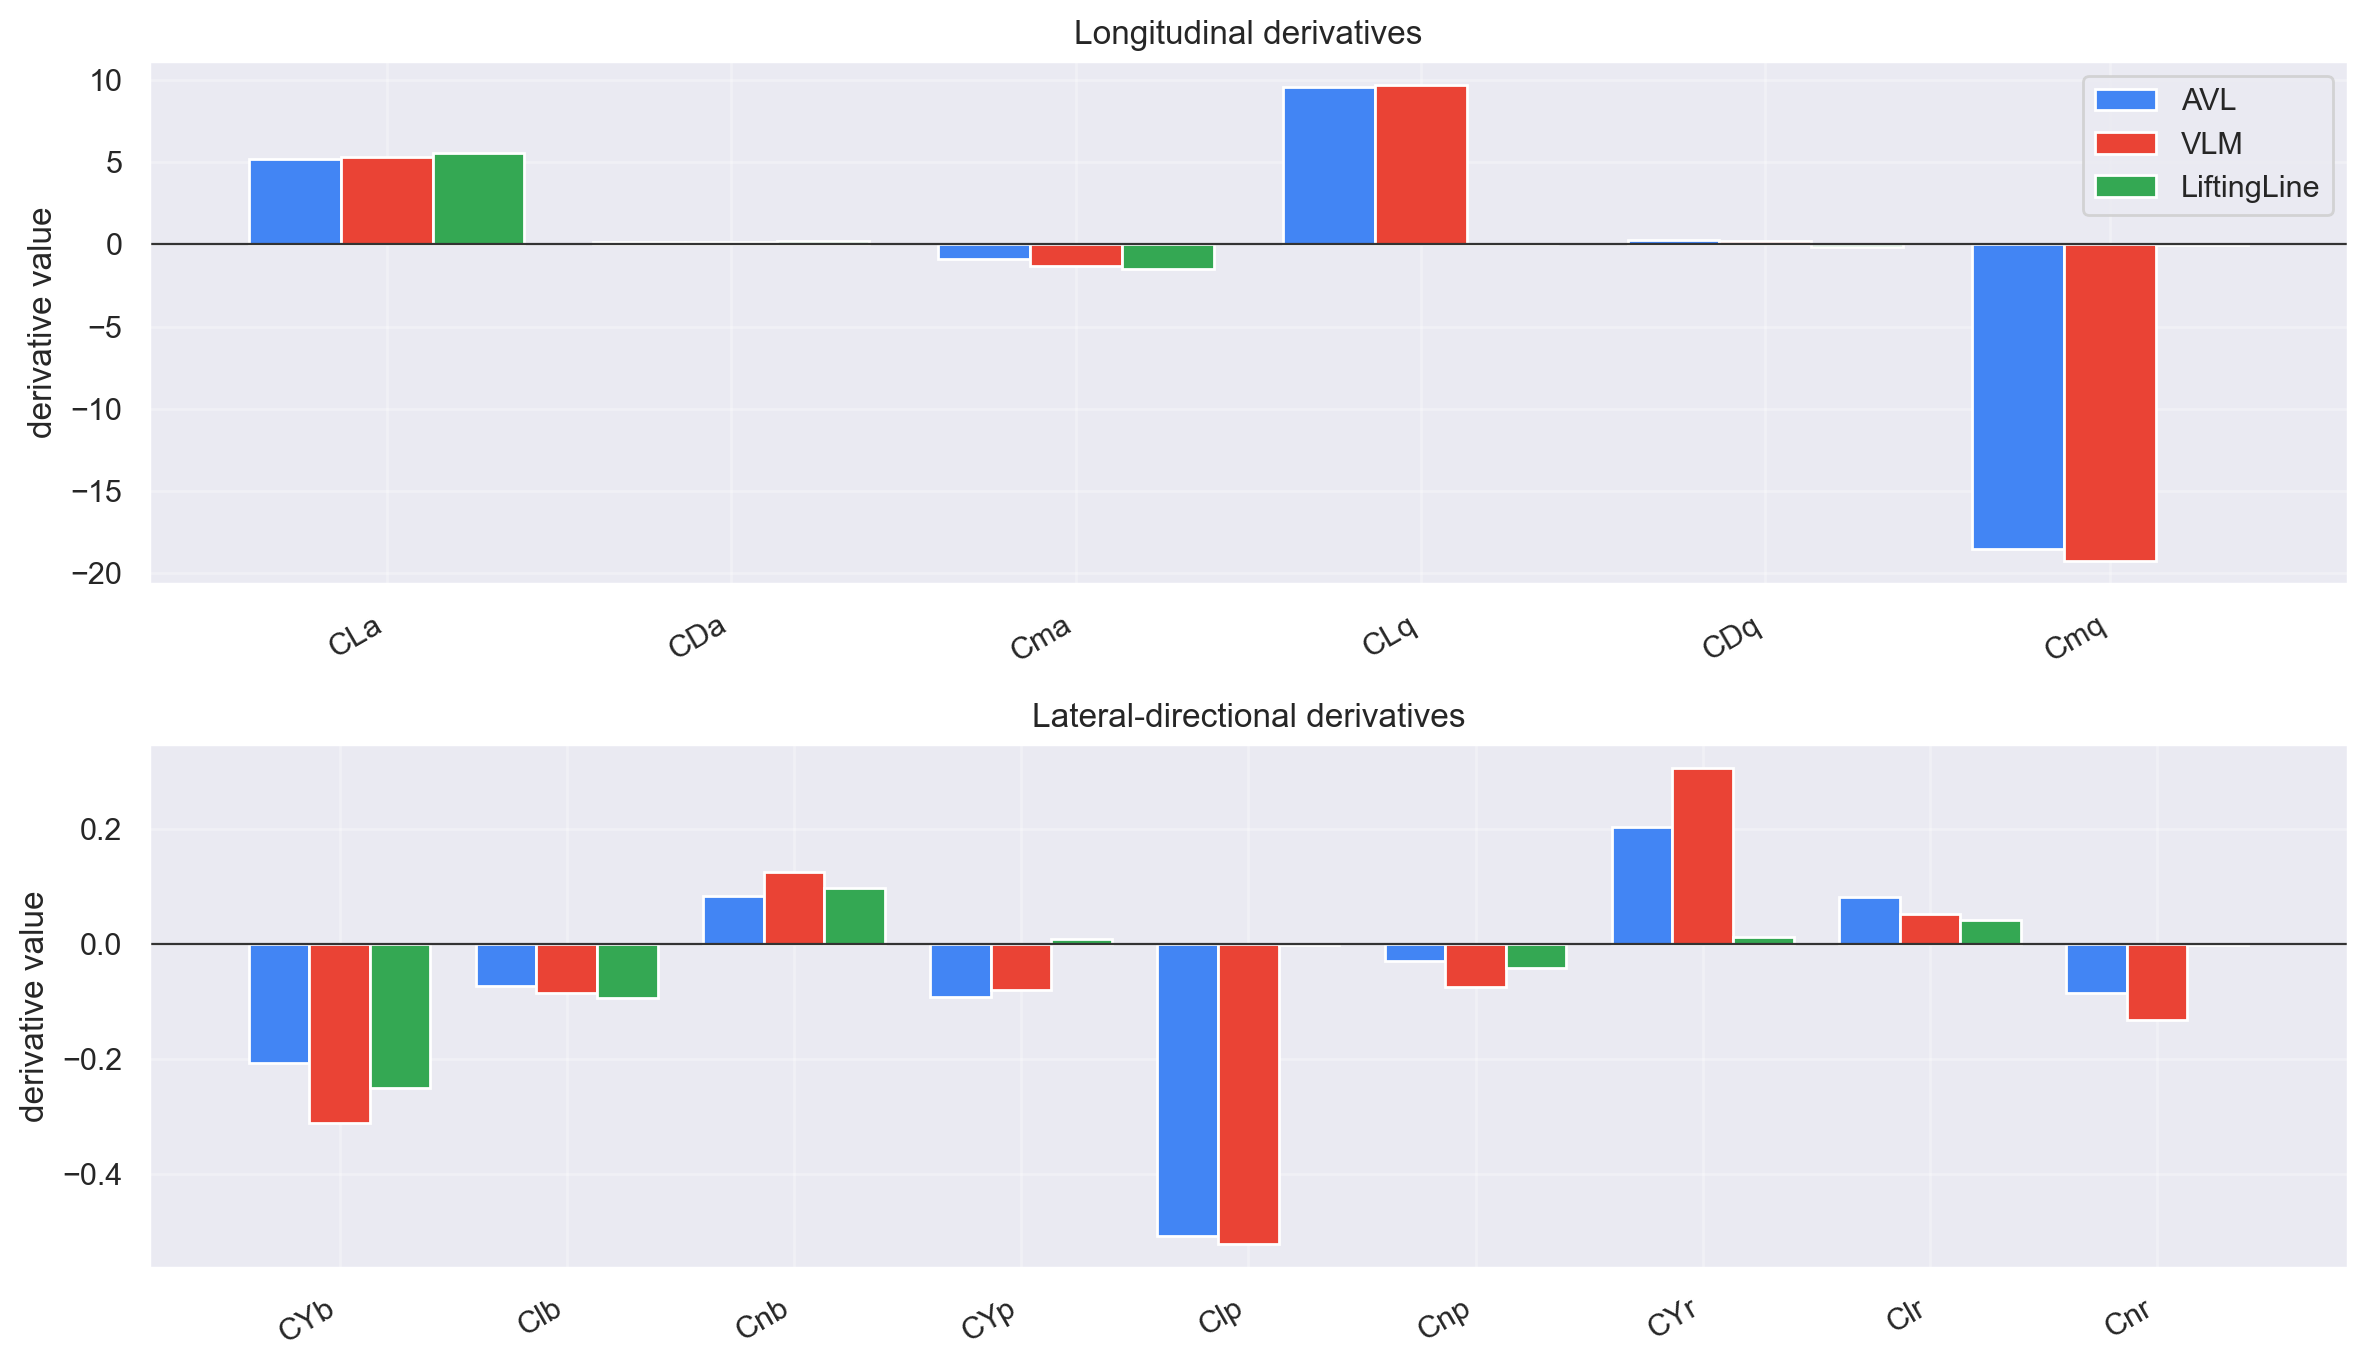

In [8]:
coefficient_keys = ["CL", "CD", "CY", "Cl", "Cm", "Cn"]
derivative_suffixes = ["a", "b", "p", "q", "r"]
derivative_keys = [f"{coefficient}{suffix}" for suffix in derivative_suffixes for coefficient in coefficient_keys]
derivative_keys = [key for key in derivative_keys if key in derivative_df.columns]

derivative_values = derivative_df.melt(
    id_vars=["case", "method", "alpha", "beta"],
    value_vars=derivative_keys,
    var_name="derivative",
    value_name="value",
).dropna()

design_derivatives = derivative_values[derivative_values["case"] == "design"].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharey=False)
longitudinal = ["CLa", "CDa", "Cma", "CLq", "CDq", "Cmq"]
lateral = ["CYb", "Clb", "Cnb", "CYp", "Clp", "Cnp", "CYr", "Clr", "Cnr"]

grouped_bar(
    axes[0],
    design_derivatives[design_derivatives["derivative"].isin(longitudinal)],
    "derivative",
    "value",
    "Longitudinal derivatives",
    "derivative value",
)
grouped_bar(
    axes[1],
    design_derivatives[design_derivatives["derivative"].isin(lateral)],
    "derivative",
    "value",
    "Lateral-directional derivatives",
    "derivative value",
)
axes[0].legend()
fig.tight_layout();

## Stability-Derivative Absolute Error Against AVL

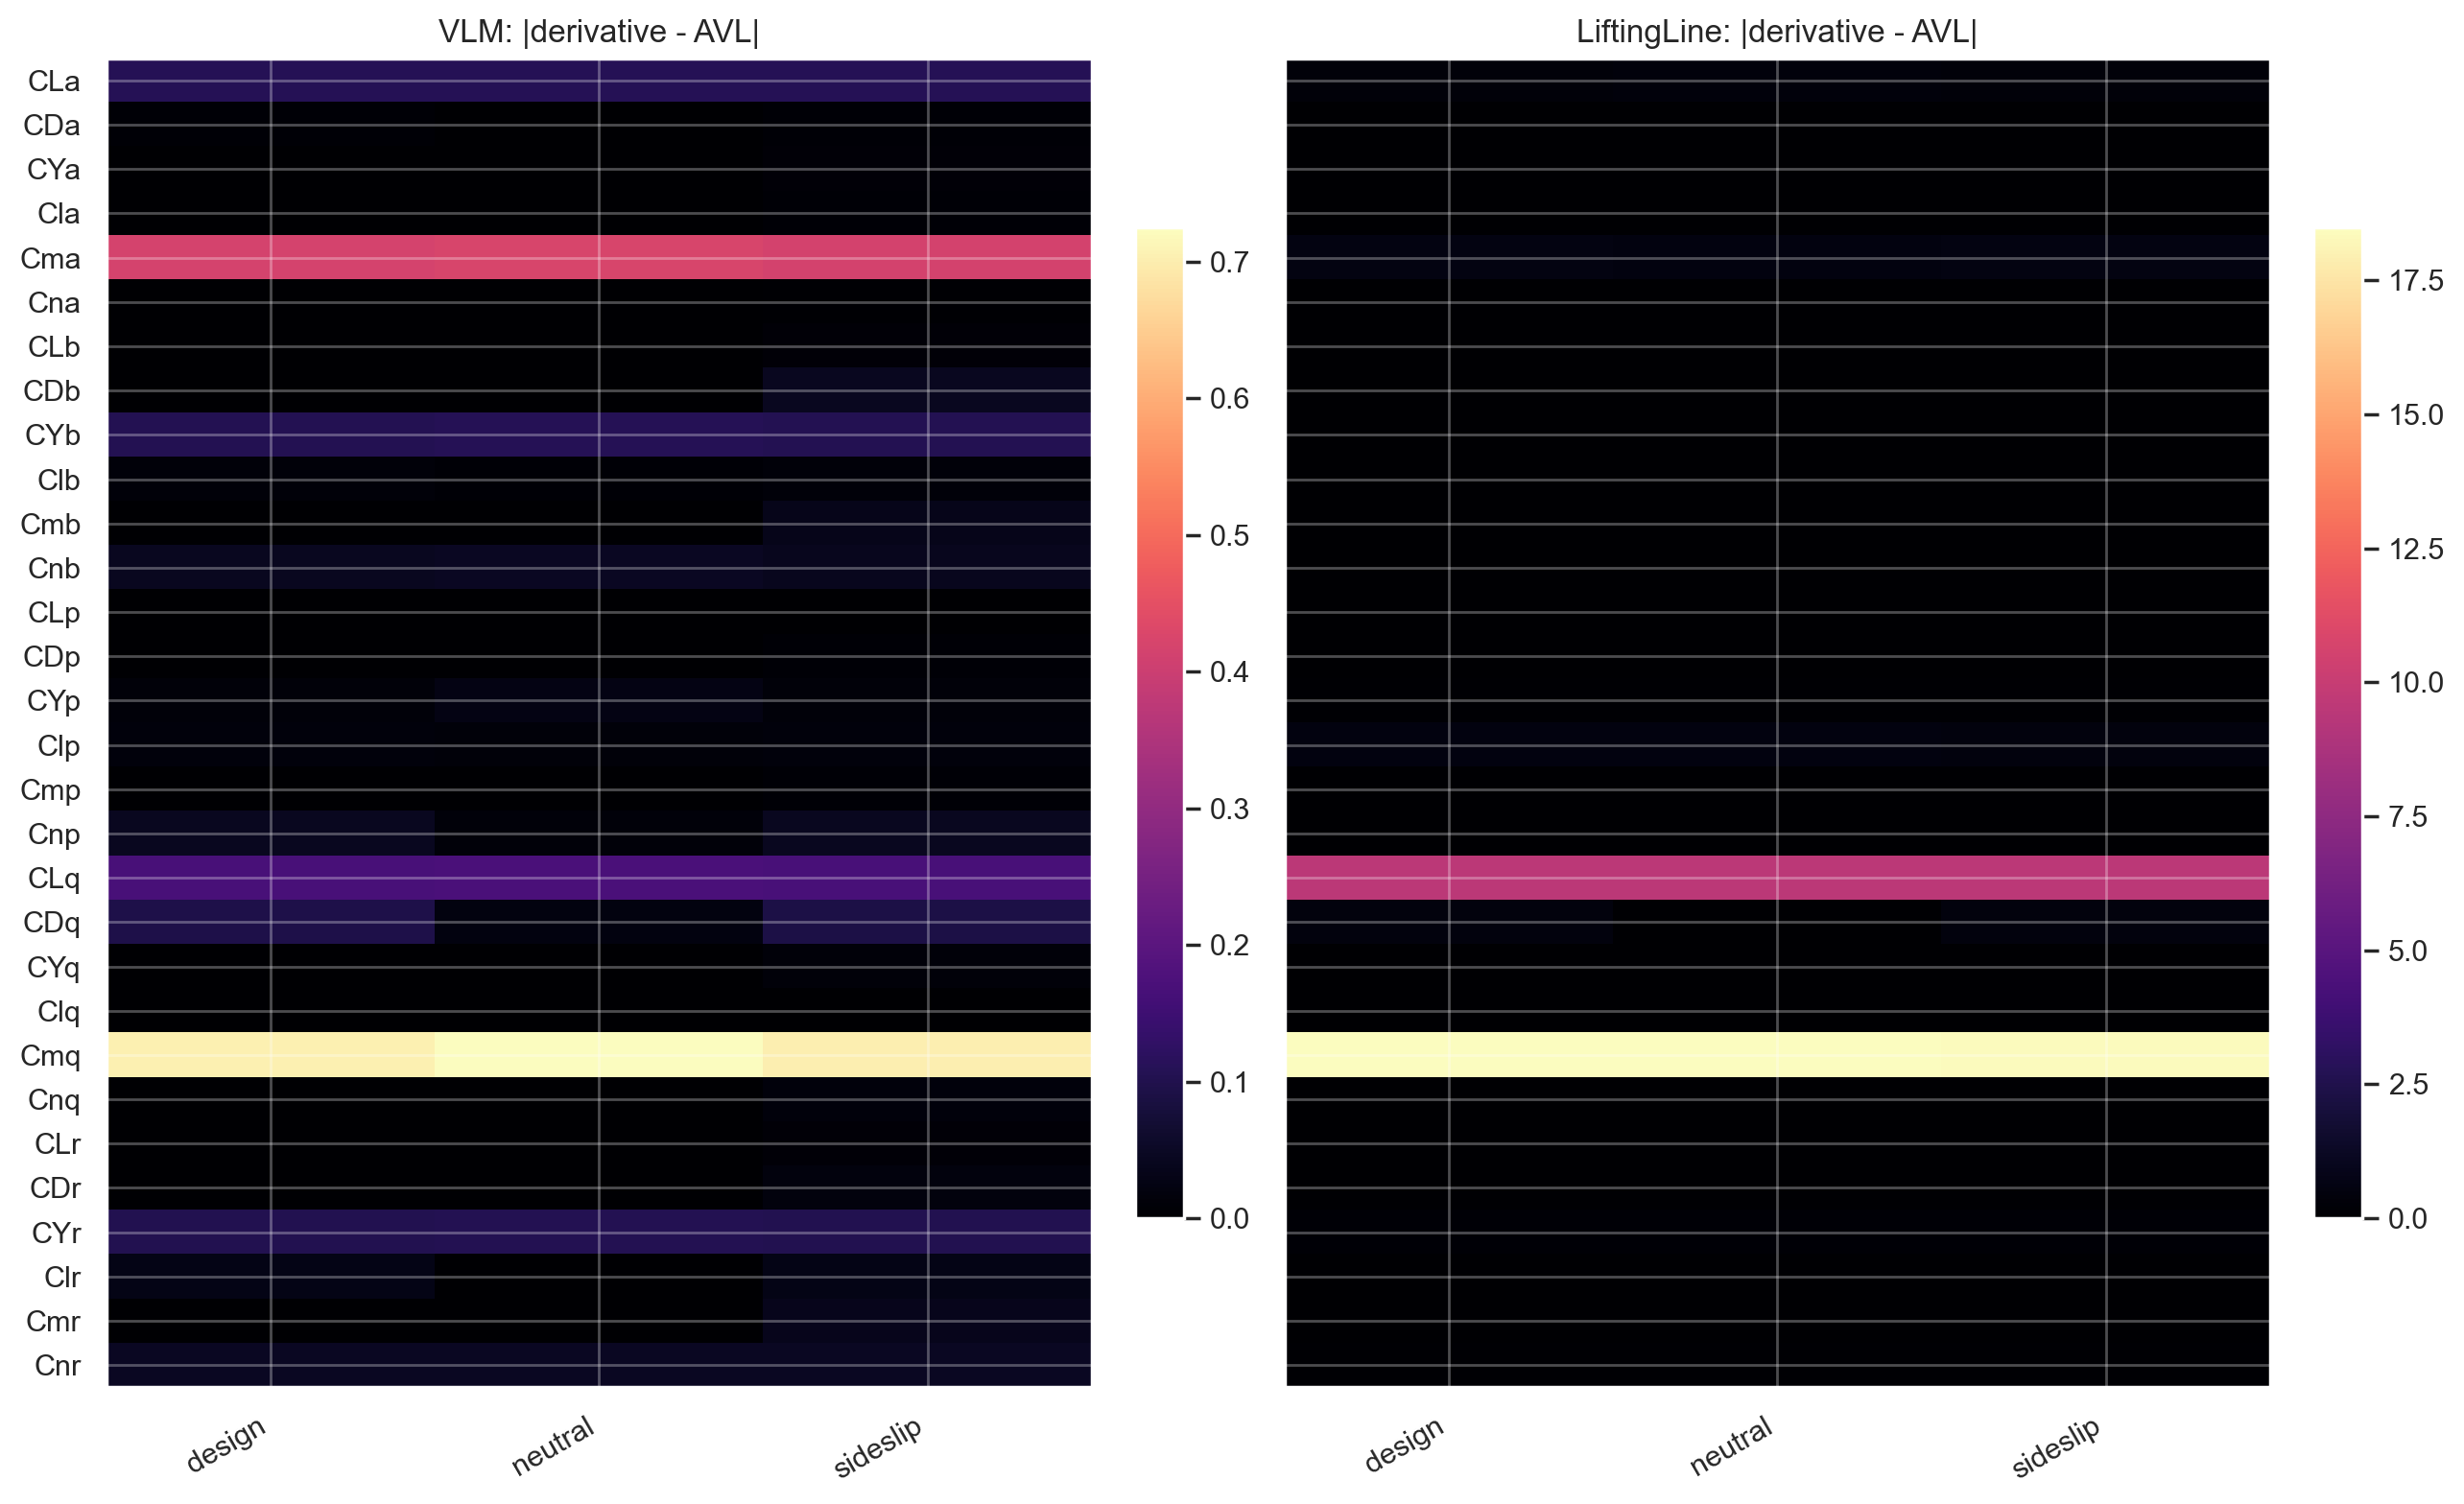

In [9]:
def derivative_error_heatmap(method):
    comp = derivative_comparison_df[derivative_comparison_df["method"] == method]
    pivot = comp.pivot_table(
        index="derivative",
        columns="case",
        values="abs_error",
        aggfunc="first",
    ).reindex(derivative_keys)
    return pivot

fig, axes = plt.subplots(1, 2, figsize=(13, 8), sharey=True)

for ax, method in zip(axes, ["VLM", "LiftingLine"]):
    pivot = derivative_error_heatmap(method)
    data = np.abs(pivot.to_numpy(dtype=float))
    im = ax.imshow(data, aspect="auto", cmap="magma")
    ax.set_title(f"{method}: |derivative - AVL|")
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=30, ha="right")
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout();

## Spanwise Lift Distributions

,method,wing,has_projected_y_span,n_strips,finite_horizontal_lift_distribution,max_abs_lift,max_abs_clc_over_cref,clc_over_cref_spike_ratio,sum_lift
0,VLM,Main Wing,True,48,True,2.077016e+02,0.473469,1.360675,4.709293e+03
1,VLM,Horizontal Tail,True,24,True,2.143094e+01,0.085902,1.118331,3.008849e+02
2,VLM,Vertical Tail,False,12,True,3.631100e-31,NaN,NaN,-2.500507e-31
3,LiftingLine,Main Wing,True,48,True,2.205998e+02,0.507139,1.410395,4.995789e+03
4,LiftingLine,Horizontal Tail,True,24,True,2.074113e+01,0.082700,1.105764,2.989081e+02
5,LiftingLine,Vertical Tail,False,12,True,5.189111e-31,NaN,NaN,-1.803533e-30


,method,wing_index,wing,strip_index,y_m,dy_m,chord_m,lift_N,lift_per_y_N_per_m,cl,clc_over_cref
0,VLM,0,Main Wing,0,-4.977846,0.042589,0.654259,3.140013e+00,73.727993,0.090856,0.050941
1,VLM,0,Main Wing,1,-4.894120,0.124863,0.671006,1.472656e+01,117.941880,0.141713,0.081490
2,VLM,0,Main Wing,2,-4.732378,0.198621,0.703358,3.297297e+01,166.009187,0.190294,0.114701
3,VLM,0,Main Wing,3,-4.503649,0.258836,0.749110,5.519897e+01,213.258606,0.229525,0.147347
4,VLM,0,Main Wing,4,-4.223530,0.301403,0.805146,7.846686e+01,260.338828,0.260696,0.179876
5,VLM,0,Main Wing,5,-3.911117,0.323424,0.867645,9.949423e+01,307.628160,0.285860,0.212550
6,VLM,0,Main Wing,6,-3.587704,0.323402,0.932350,1.145173e+02,354.102461,0.306210,0.244660
7,VLM,0,Main Wing,7,-3.275332,0.301342,0.994850,1.198117e+02,397.593208,0.322218,0.274709
8,VLM,0,Main Wing,8,-2.995285,0.258753,1.050887,1.127020e+02,435.558014,0.334164,0.300940
9,VLM,0,Main Wing,9,-2.766639,0.198539,1.096640,9.249302e+01,465.869058,0.342506,0.321883


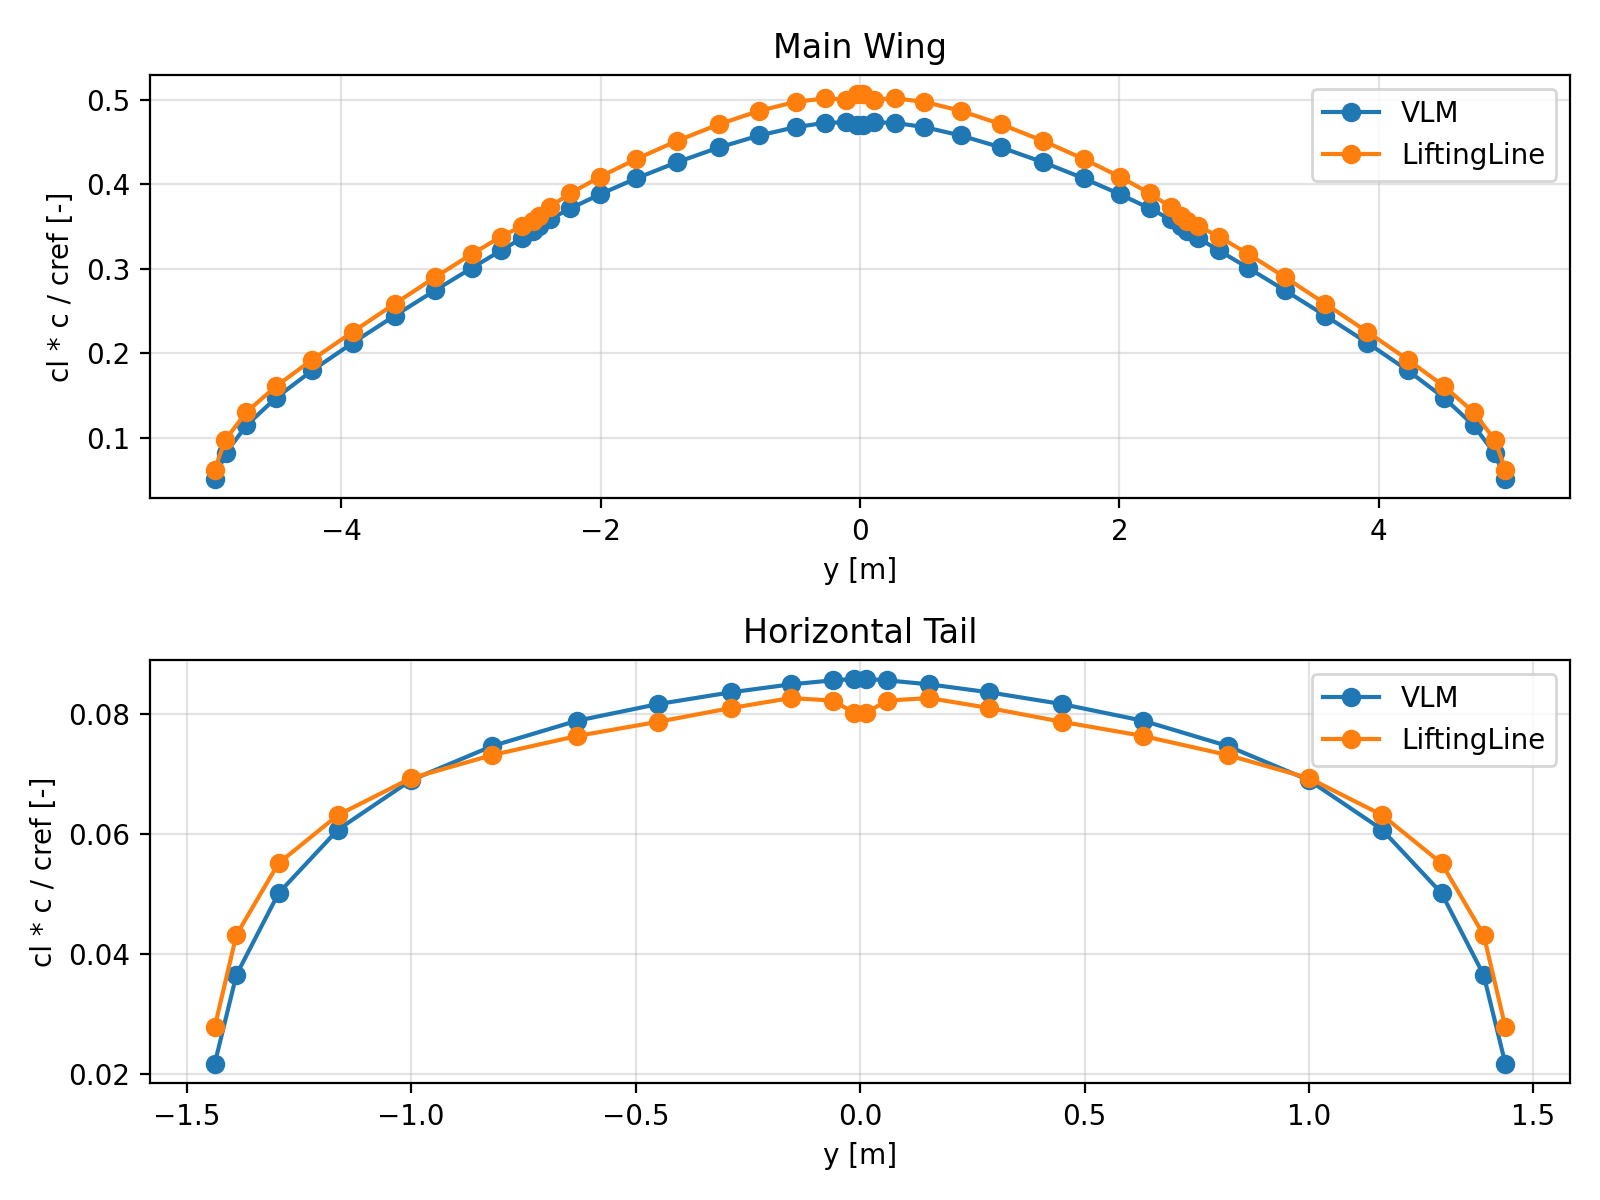

In [10]:
display(distribution_df)

distribution_op_point = validation.make_op_point(alpha=4.0, beta=0.0)
vlm_distribution = validation.run_vlm(airplane, distribution_op_point)
lifting_line_distribution = validation.run_lifting_line(airplane, distribution_op_point)

def lift_distribution_table(result, method):
    rows = []
    for wing_index, wing in enumerate(airplane.wings):
        n_strips = len(result["y"][wing_index])
        for strip_index in range(n_strips):
            rows.append({
                "method": method,
                "wing_index": wing_index,
                "wing": wing.name,
                "strip_index": strip_index,
                "y_m": float(result["y"][wing_index][strip_index]),
                "dy_m": float(result["dy"][wing_index][strip_index]),
                "chord_m": float(result["chord"][wing_index][strip_index]),
                "lift_N": float(result["lift"][wing_index][strip_index]),
                "lift_per_y_N_per_m": float(result["lift_per_y"][wing_index][strip_index]),
                "cl": float(result["cl"][wing_index][strip_index]),
                "clc_over_cref": float(result["clc_over_cref"][wing_index][strip_index]),
            })
    return pd.DataFrame(rows)

lift_distribution_df = pd.concat([
    lift_distribution_table(vlm_distribution, "VLM"),
    lift_distribution_table(lifting_line_distribution, "LiftingLine"),
], ignore_index=True)

pd.set_option("display.max_rows", 200)
display(lift_distribution_df)

lift_distribution_plot = OUTPUT_DIR / "lift_distributions.png"
if lift_distribution_plot.exists():
    display(Image(filename=str(lift_distribution_plot)))
else:
    print(f"Missing lift distribution plot: {lift_distribution_plot}")